# WASSA 2024 Shared Task

This notebook summarizes the **WASSA 2024 Shared Task on Empathy and Personality Detection in Interactions**
* [Findings paper](https://aclanthology.org/2024.wassa-1.30.pdf)
* [CodaLab competition #18810](https://codalab.lisn.upsaclay.fr/competitions/18810)

## Introduction

Participants (crowd workers) **read news articles** (often about harm to a person, group, or nature), and **wrote a short essay** (300–800 characters) about how the article made them feel. They then self-reported their **empathy and distress** (Batson scale), filled out **personality** (Big Five), IRI, and demographic surveys. Participants then had a **conversation** about the article with a partner (person or an AI).

Every conversation turn (≥10 turns/person in train/dev, 15 in test) was later **third-party annotated** for empathy and emotion. The shared task asks teams to **predict** these human signals from text.

It is a new, unpublished extension of the WASSA 2023 dataset (originally from Omitaomu et al., 2022), with two new components this year: participants rated their conversational **partner's** empathy, and some conversations were with a **conversational AI** system.

### The four tasks

| Track | Name | Source | Predict | Output |
|---|---|---|---|---|
| 1 | **CONV-Dialog** | whole dialog | perceived empathy of the partner | 1 score (1–7) |
| 2 | **CONV-Turn** | each chat turn | emotion polarity, emotion intensity, empathy | 3 scores |
| 3 | **EMP** | each essay | empathic concern, personal distress | 2 scores (1–7) |
| 4 | **PER** | each essay | Big Five / OCEAN personality | 5 scores |

### Evaluation

Everything is scored with the **Pearson product-moment correlation** (−1 to 1; higher = predictions track the true values better). For tasks with multiple targets, the official metric is the **average** of the per-target correlations.

**Note:** The dataset should live in the **`data/wassa2024/`** folder of this repo, one comma-separated file per task and split.

In [1]:
from pathlib import Path
import pandas as pd
import plotnine as p9

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## Prepare data

In [2]:
from pathlib import Path
import pandas as pd

datafolder = Path("../../data/wassa2024")

turns = pd.read_csv(datafolder / "trac2_CONVT_train.csv", escapechar="\\")    # turn-level annotations
dialog = pd.read_csv(datafolder / "trac1_CONVD_train.csv", escapechar="\\")   # post-conversation perceived empathy
dialog = dialog.rename(
    columns={
        "person_id_1": "person_id",
        "this_persons_perceived_empathy_of_other_person": "perceived_empathy_of_other_person",
    }
)
essays = pd.read_csv(datafolder / "trac3_EMP_train.csv", escapechar="\\")     # essays + state empathy/distress
persons = pd.read_csv(datafolder / "trac4_PER_train.csv", escapechar="\\")    # per-person traits/demographics
persons = persons.drop(columns=["id"])

# 1. Conversation turns — one row per turn, with all turn-level annotations.
conversations = pd.DataFrame(
    {
        "conversation_id": turns["conversation_id"],
        "speaker_id": turns["person_id_1"].where(turns["speaker"].eq("Person 1"), turns["person_id_2"]),
        "turn_id": turns["turn_id"],
        "text": turns["text"],
        "emotion": turns["Emotion"],
        "emotional_polarity": turns["EmotionalPolarity"],
        "empathy": turns["Empathy"],
        "self_disclosure": turns["SelfDisclosure"],
    }
)

# 2. Surveys — per-person self-report gathered AFTER each conversation (perceived empathy
# of the partner) joined to that person's stable self-reported traits/demographics.
surveys = pd.merge(
    dialog, 
    persons, 
    on="person_id", 
    how="left"
)
surveys = surveys.rename(columns={"personality_openess": "personality_openness"})

# 3. Essays — each essay, the participants who wrote it, and the article they responded to.
essays = essays.rename(
    columns={
        "person_essay": "essay",
        "person_empathy": "essay_empathy",
        "person_distress": "essay_distress",
    }
)
essays = essays[["article_id", "person_id", "conversation_id", "essay", "essay_empathy", "essay_distress"]]

for name, df in [
    ("conversations", conversations),
    ("surveys", surveys),
    ("essays", essays)
]:
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} cols")
    print("Columns:", list(df.columns))
    print("-" * 40)

display(conversations.head())
display(surveys.head())
display(essays.head())

conversations: 11166 rows x 8 cols
Columns: ['conversation_id', 'speaker_id', 'turn_id', 'text', 'emotion', 'emotional_polarity', 'empathy', 'self_disclosure']
----------------------------------------
surveys: 1000 rows x 19 cols
Columns: ['id', 'conversation_id', 'article_id', 'person_id', 'perceived_empathy_of_other_person', 'gender', 'education', 'race', 'age', 'income', 'iri_perspective_taking', 'iri_personal_distress', 'iri_fantasy', 'iri_empathatic_concern', 'personality_openness', 'personality_conscientiousness', 'personality_extraversion', 'personality_agreeableness', 'personality_stability']
----------------------------------------
essays: 1000 rows x 6 cols
Columns: ['article_id', 'person_id', 'conversation_id', 'essay', 'essay_empathy', 'essay_distress']
----------------------------------------


,conversation_id,speaker_id,turn_id,text,emotion,emotional_polarity,empathy,self_disclosure
0,1,p019,0,what did you think about this article,0.6667,1.0,0.6667,1.0000
1,1,p012,1,"It's definitely really sad to read, considerin...",3.0000,2.0,4.3333,2.0000
2,1,p019,2,I think it's super sad... they seem to never c...,3.6667,2.0,4.6667,2.6667
3,1,p012,3,I can't imagine just living in an area that is...,3.0000,2.0,4.6667,3.3333
4,1,p019,4,Me too.. I also can't imagine living in the po...,3.3333,2.0,4.6667,3.0000


,id,conversation_id,article_id,person_id,perceived_empathy_of_other_person,gender,education,race,age,income,iri_perspective_taking,iri_personal_distress,iri_fantasy,iri_empathatic_concern,personality_openness,personality_conscientiousness,personality_extraversion,personality_agreeableness,personality_stability
0,1,1,35,p019,6,2,2,1,21,20000,2.714286,3.000000,3.142857,3.285714,3.00,5.00,5.00,4.00,3.5
1,2,2,35,p035,7,1,6,3,37,40000,4.857143,2.000000,3.428571,5.000000,5.50,7.00,1.00,6.50,6.0
2,3,3,35,p024,5,1,6,2,32,35000,3.428571,2.857143,2.857143,2.714286,5.00,5.50,2.00,5.50,4.5
3,4,4,35,p041,5,1,6,3,33,64000,3.714286,1.000000,2.428571,1.428571,7.00,6.50,3.50,4.50,7.0
4,5,5,35,p022,7,1,6,1,29,85000,4.642857,2.071429,4.142857,4.642857,6.75,6.75,6.75,6.75,7.0


,article_id,person_id,conversation_id,essay,essay_empathy,essay_distress
0,35,p019,1,How sad is it that this kind of pain and suffe...,3.857143,3.285714
1,35,p035,2,It breaks my heart to see people living in tho...,6.714286,6.714286
2,35,p024,3,I wonder why there aren't more people trying t...,5.857143,6.000000
3,35,p041,4,The article is kind of tragic and hits close t...,2.714286,1.000000
4,35,p022,5,"After reading the article, you can't help but ...",1.000000,1.428571


## Descriptives

Computed from the prepared tables — number of conversations and participants, participant demographics, self-reported OCEAN and IRI distributions, and turns per conversation.

In [3]:
print(f"conversations: {surveys['conversation_id'].nunique()}")
print(f"participants: {surveys['person_id'].nunique()}")

conversations \
    .groupby("conversation_id") \
    .agg({"turn_id": "count"}) \
    .rename(columns={"turn_id": "Turns per conversation"}) \
    .describe() \
    .round(2)

conversations: 500
participants: 75


,Turns per conversation
count,487.00
mean,22.93
std,4.07
min,13.00
25%,20.00
50%,22.00
75%,24.00
max,44.00


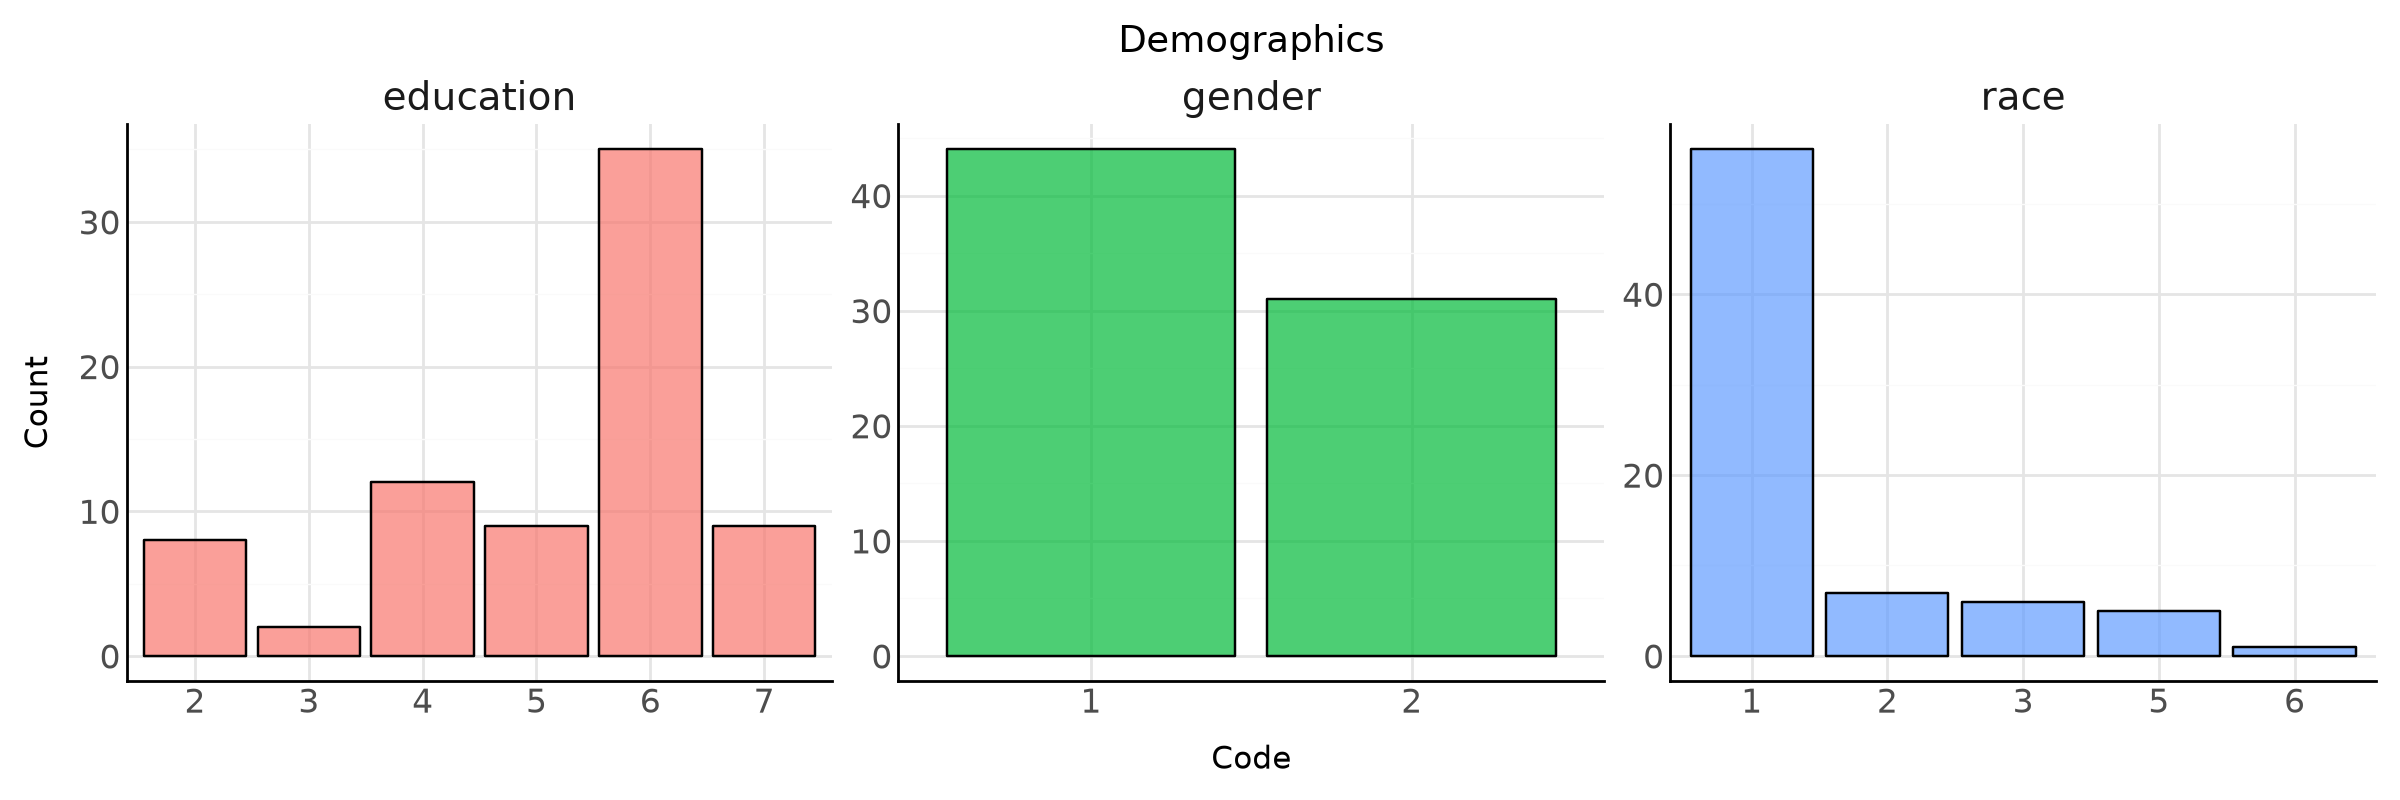

In [4]:
# Demographic distributions — categorical survey codes (one row per participant).
categorical = surveys.drop_duplicates("person_id")[["gender", "education", "race"]]
categorical = categorical.melt(var_name="variable", value_name="code")

(
    p9.ggplot(categorical, p9.aes(x="factor(code)", fill="variable")) +
    p9.geom_bar(color="black", alpha=0.7) +
    p9.facet_wrap("variable", scales="free", ncol=3) +
    p9.labs(
        title="Demographics",
        x="Code",
        y="Count",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
        legend_position="none"
    )
)

#FIXME: get codebook for variables

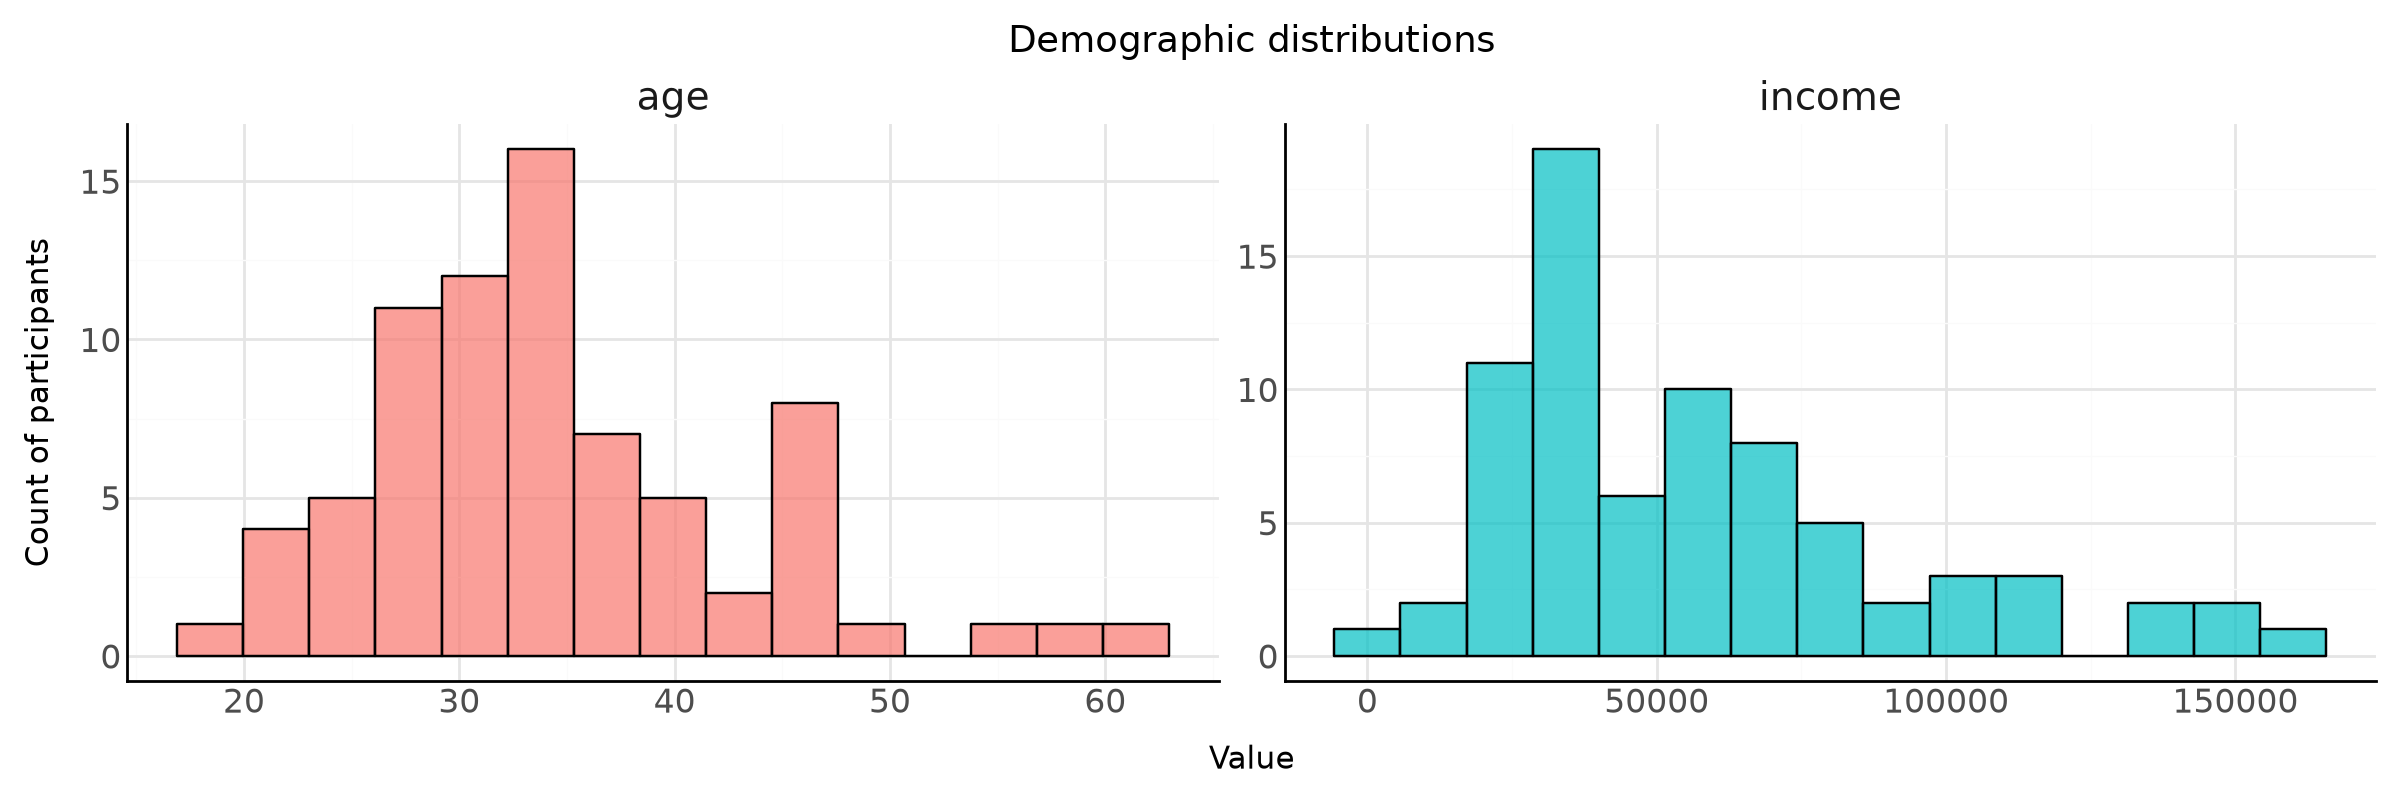

In [5]:
numerical = surveys.drop_duplicates("person_id")[["age", "income"]]
numerical = numerical.melt(var_name="variable", value_name="value")

(
    p9.ggplot(numerical, p9.aes(x="value", fill="variable")) +
    p9.geom_histogram(bins=15, color="black", alpha=0.7) +
    p9.facet_wrap("variable", scales="free", ncol=2) +
    p9.labs(
        title="Demographic distributions",
        x="Value",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        legend_position="none",
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

# mostly young adults, who have income ~50K pa.

,count,mean,std,min,25%,50%,75%,max
personality_openness,75.0,5.30,1.33,2.0,4.0,5.5,6.25,7.0
personality_conscientiousness,75.0,5.70,1.17,2.5,5.5,6.0,6.50,7.0
personality_extraversion,75.0,3.62,1.86,1.0,2.0,3.5,5.00,7.0
personality_agreeableness,75.0,5.47,1.18,2.0,4.5,5.5,6.50,7.0
personality_stability,75.0,5.02,1.59,1.0,4.0,5.5,6.00,7.0


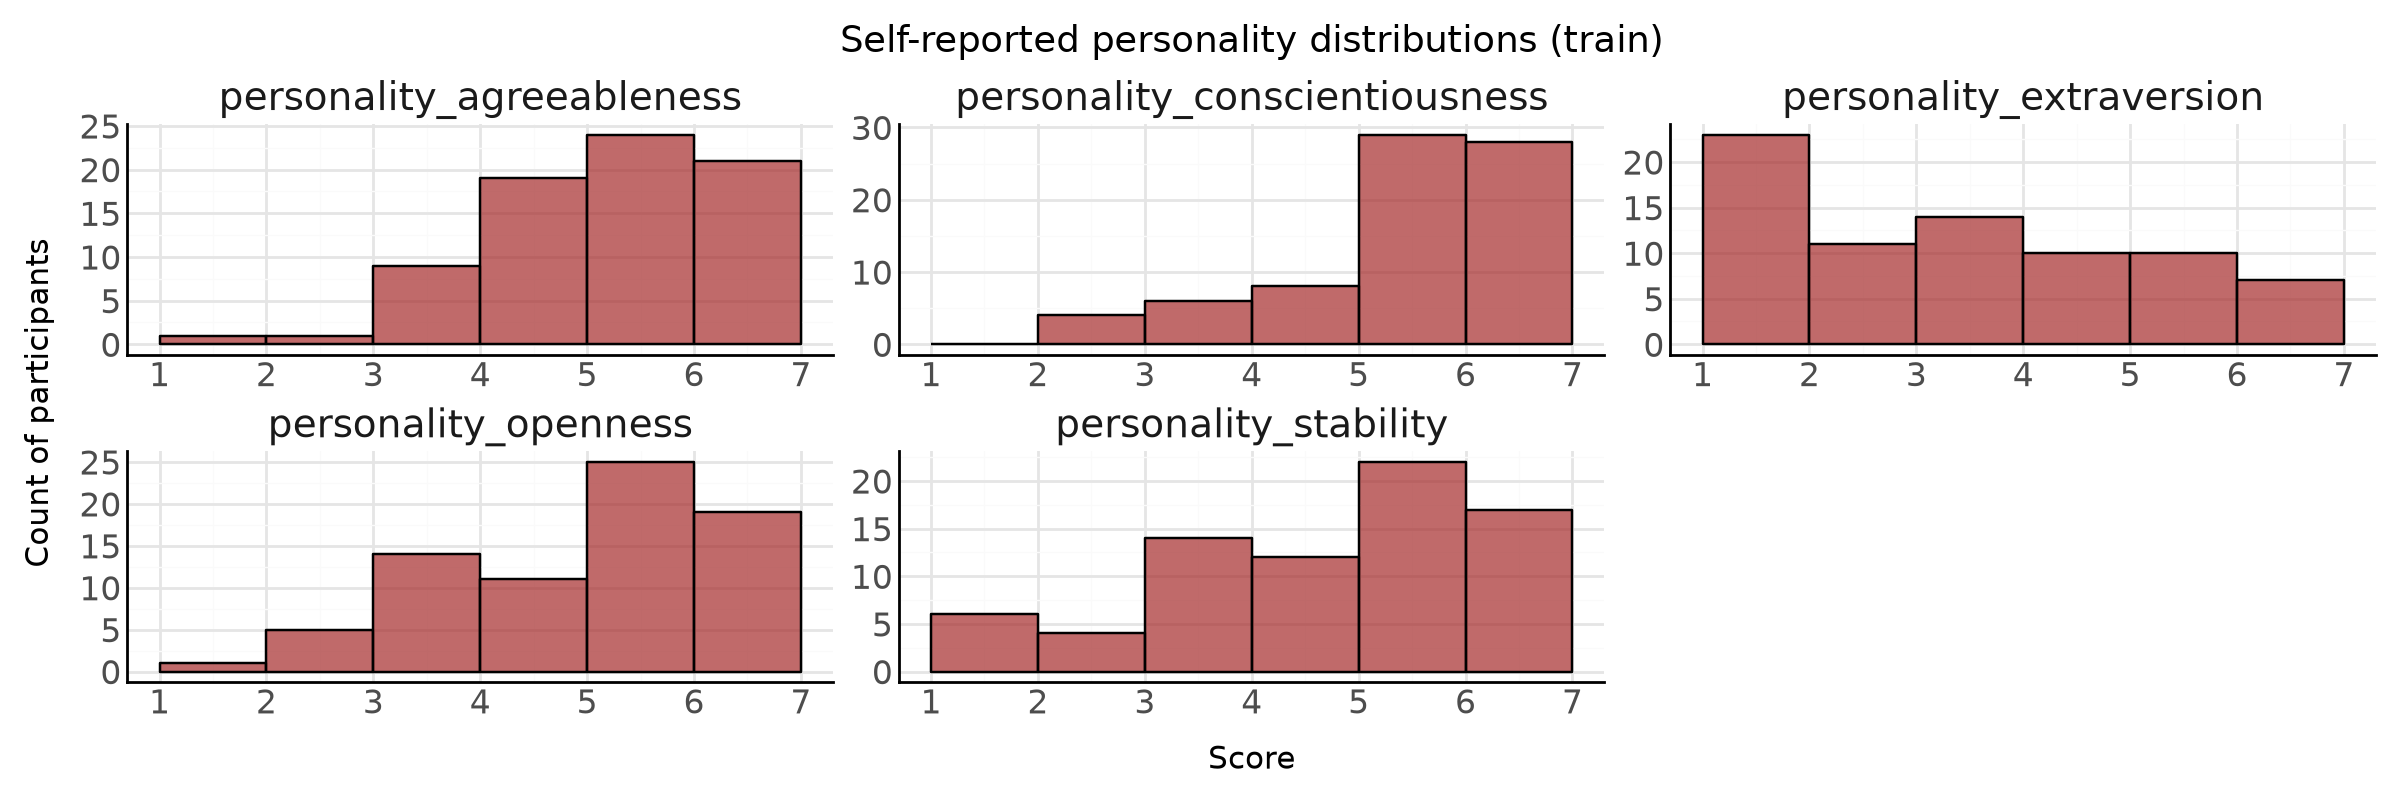

In [6]:
personality = surveys.drop_duplicates("person_id")[[
    "personality_openness",
    "personality_conscientiousness",
    "personality_extraversion",
    "personality_agreeableness",
    "personality_stability",
]]

display(personality.describe().round(2).T)

personality = personality.melt(var_name="trait", value_name="score")
(
    p9.ggplot(personality, p9.aes(x="score")) +
    p9.geom_histogram(breaks=range(1, 8), fill="brown", color="black", alpha=0.7) +
    p9.facet_wrap("trait", scales="free", ncol=3) +
    p9.scale_x_continuous(breaks=range(1, 8)) +
    p9.labs(
        title="Self-reported personality distributions (train)",
        x="Score",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

#FIXME: check how people skew in general, and then for this demographics.

,count,mean,std,min,25%,50%,75%,max
iri_perspective_taking,75.0,3.88,0.79,1.86,3.39,4.00,4.50,5.00
iri_personal_distress,75.0,2.46,0.83,1.00,1.93,2.43,2.93,4.43
iri_fantasy,75.0,3.49,0.90,1.57,2.86,3.43,4.21,5.00
iri_empathatic_concern,75.0,3.83,0.96,1.43,3.29,3.86,4.68,5.00


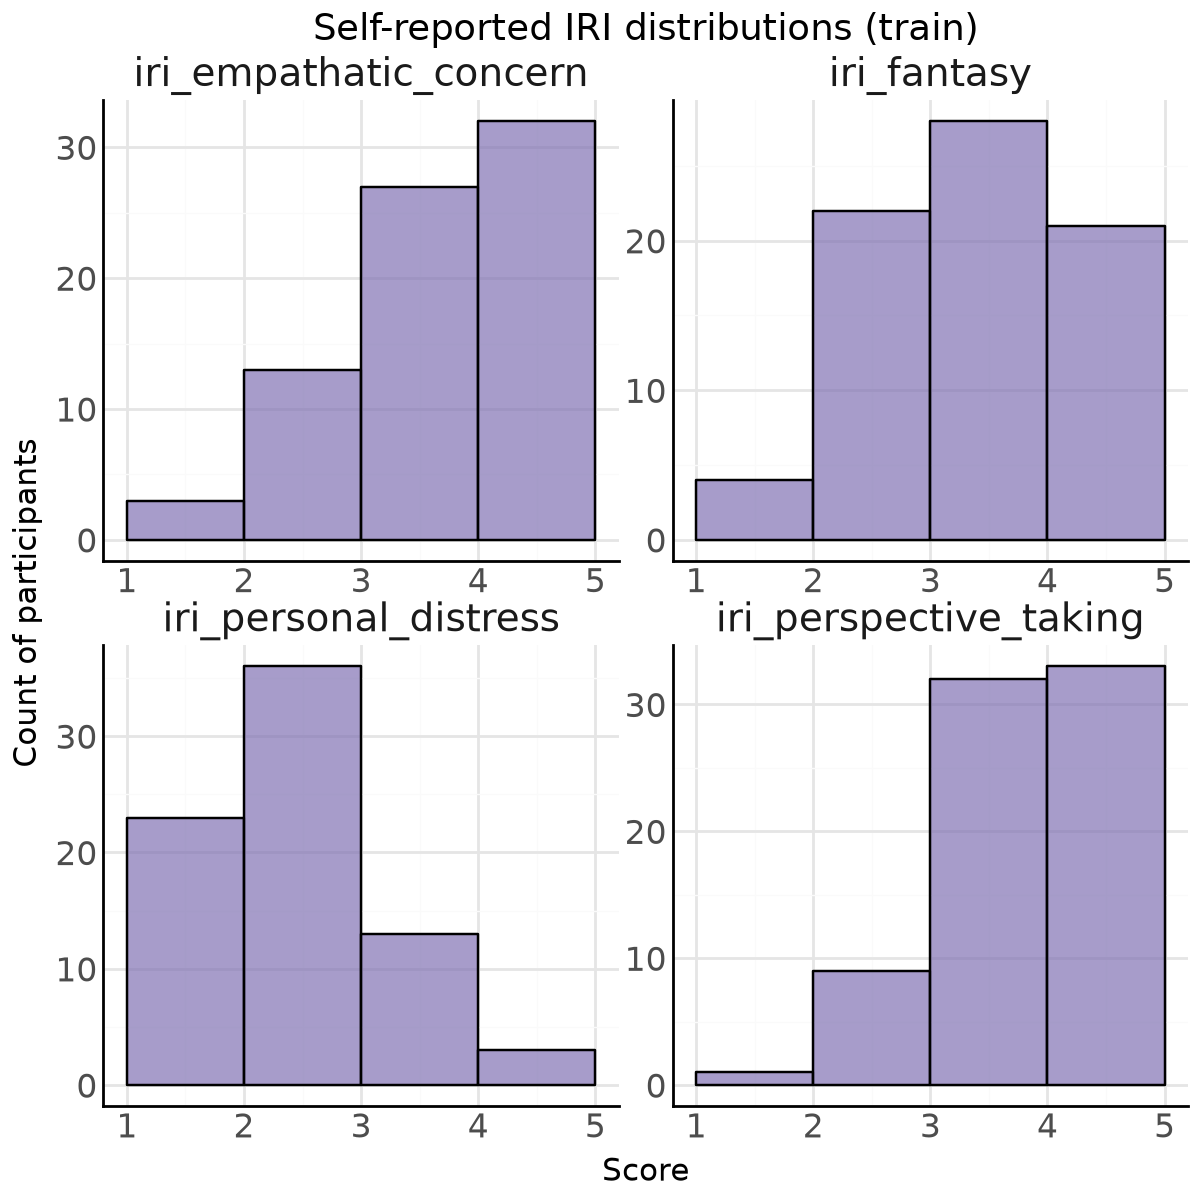

In [7]:
iri = surveys.drop_duplicates("person_id")[[
    "iri_perspective_taking",
    "iri_personal_distress",
    "iri_fantasy",
    "iri_empathatic_concern",
]]

display(iri.describe().round(2).T)

iri = iri.melt(var_name="trait", value_name="score")
(
    p9.ggplot(iri, p9.aes(x="score")) +
    p9.geom_histogram(breaks=range(1, 6), fill="#8172B3", color="black", alpha=0.7) +
    p9.facet_wrap("trait", scales="free", ncol=2) +
    p9.scale_x_continuous(breaks=range(1, 6)) +
    p9.labs(
        title="Self-reported IRI distributions (train)",
        x="Score",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(6, 6),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

In [8]:
# Export the three prepared dataframes as CSV into data/wassa2024/train.
train_dir = datafolder / "train"
train_dir.mkdir(parents=True, exist_ok=True)

for name, df in [("conversations", conversations), ("surveys", surveys), ("essays", essays)]:
    out_path = train_dir / f"{name}.csv"
    df.to_csv(out_path, index=False)
    print(f"wrote {out_path}  ({df.shape[0]} rows x {df.shape[1]} cols)")

wrote ../data/wassa2024/train/conversations.csv  (11166 rows x 8 cols)
wrote ../data/wassa2024/train/surveys.csv  (1000 rows x 19 cols)
wrote ../data/wassa2024/train/essays.csv  (1000 rows x 6 cols)


## Experiments

### Read the conversation and survey data

In [9]:
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

datafolder = Path("../../data/wassa2024/train")

conversations = pd.read_csv(datafolder / "conversations.csv")
surveys = pd.read_csv(datafolder / "surveys.csv")

/home/ssubrahmanya/summary-mem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


### Store both speakers' turns into summary-mem

Iterate over conversations and, turn by turn, update the rolling per-speaker summary in a `SummaryMemory` store.

In [15]:
import numpy as np
from summary_mem import SummaryMemory
from summary_mem.clients import get_chat_client

rng = np.random.default_rng(42)
    
# Fresh store so re-running this cell starts from an empty memory.
database = Path("wassa2024_memory.db")
if database.exists():
    database.unlink(missing_ok=True)

client = get_chat_client()
memory = SummaryMemory(client, db_path=database)

conversation_ids = conversations["conversation_id"].unique()

num_sample = 1
sample_conversation_ids = rng.choice(
    conversation_ids, 
    size=num_sample, 
    replace=False
)

for conversation_id in tqdm(sample_conversation_ids, desc="storing conversations"):

    # read all turns for this conversation, sorted by turn_id
    turns = conversations[conversations["conversation_id"] == conversation_id]
    turns = turns.sort_values("turn_id")

    for index, turn in turns.iterrows():

        conversation_id, speaker_id, turn_text = (
            str(turn["conversation_id"]), 
            str(turn["speaker_id"]), 
            turn["text"]
        )

        memory.update(
            conversation_id=conversation_id, 
            speaker_id=speaker_id, 
            turn_text=turn_text
        )

storing conversations: 100%|██████████| 1/1 [00:51<00:00, 51.68s/it]


### Predict personality

In [20]:
import json

TRAITS = [
    "openness", 
    "conscientiousness", 
    "extraversion", 
    "agreeableness", 
    "stability"
]

# ideally I should give the context on what's Big-V and OCEAN.
SYSTEM_PROMPT = (
    "Given a factual summary of a single person built from their side of a conversation, "
    "estimate their Big Five (OCEAN) personality traits: "
    "openness, conscientiousness, extraversion, agreeableness, and emotional stability. "
    "Score each trait on a continuous 1-7 scale (1 = very low, 7 = very high). "
    "Reply with ONLY a JSON object whose keys are exactly: "
    "openness, conscientiousness, extraversion, agreeableness, stability."
)

PERSONALITY_PREDICTION_TEMPLATE = (
    "Here is what is known about the speaker {speaker}, summarized from their conversation:\n\n{context}\n\n"
    "Estimate {speaker}'s Big Five personality trait scores (1-7) as JSON."
)

def predict_personality(speaker, context):

    response = client.chat.completions.create(
        model=memory.model,
        messages=[
            {
                "role": "system", 
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user", 
                "content": PERSONALITY_PREDICTION_TEMPLATE.format(
                    speaker=speaker, 
                    context=context
                )
            },
        ],
        temperature=0.0,
        response_format={"type": "json_object"},
    )
    scores = json.loads(response.choices[0].message.content)
    return {trait: float(scores[trait]) for trait in TRAITS}

In [23]:
predictions = []
for conversation_id in tqdm(sample_conversation_ids, desc="predicting personality traits"):

    recalled = memory.recall(conversation_id)
    for speaker, summary in recalled.items():

        pred = predict_personality(speaker, summary)
        row = {
            "conversation_id": conversation_id,
            "speaker_id": speaker,
            **{f"pred_{trait}": pred[trait] for trait in TRAITS},
        }
        predictions.append(row)

predictions = pd.DataFrame(predictions)

predicting personality traits: 100%|██████████| 1/1 [00:03<00:00,  3.32s/it]


In [35]:
from scipy.stats import pearsonr

comparison = pd.merge(
    predictions,
    surveys, 
    left_on=["conversation_id", "speaker_id"], 
    right_on=["conversation_id", "person_id"], 
    how="left"
)

# Pearson correlation between predicted and self-reported score, per trait
# (the shared task's official metric for the PER track).
for trait in TRAITS:
    valid = comparison[[f"pred_{trait}", f"personality_{trait}"]].dropna()
    r, p = pearsonr(valid[f"pred_{trait}"], valid[f"personality_{trait}"])
    print(f"{trait:18s} Pearson r = {r:.3f}  (n={len(valid)})  p-value = {p:.3e}")

openness           Pearson r = nan  (n=2)  p-value = nan
conscientiousness  Pearson r = -1.000  (n=2)  p-value = 1.000e+00
extraversion       Pearson r = nan  (n=2)  p-value = nan
agreeableness      Pearson r = -1.000  (n=2)  p-value = 1.000e+00
stability          Pearson r = 1.000  (n=2)  p-value = 1.000e+00


/tmp/ipykernel_1213452/3159552236.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


In [20]:
surveys.head(5)

,id_x,conversation_id,article_id,person_id,perceived_empathy_of_other_person,id_y,gender,education,race,age,income,iri_perspective_taking,iri_personal_distress,iri_fantasy,iri_empathatic_concern,personality_openess,personality_conscientiousness,personality_extraversion,personality_agreeableness,personality_stability
0,1,1,35,p019,6,19,2,2,1,21,20000,2.714286,3.000000,3.142857,3.285714,3.00,5.00,5.00,4.00,3.5
1,2,2,35,p035,7,35,1,6,3,37,40000,4.857143,2.000000,3.428571,5.000000,5.50,7.00,1.00,6.50,6.0
2,3,3,35,p024,5,24,1,6,2,32,35000,3.428571,2.857143,2.857143,2.714286,5.00,5.50,2.00,5.50,4.5
3,4,4,35,p041,5,41,1,6,3,33,64000,3.714286,1.000000,2.428571,1.428571,7.00,6.50,3.50,4.50,7.0
4,5,5,35,p022,7,22,1,6,1,29,85000,4.642857,2.071429,4.142857,4.642857,6.75,6.75,6.75,6.75,7.0
